In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [3]:
from google.colab import files

uploaded = files.upload()

Saving 15m_data.csv to 15m_data (1).csv


In [4]:
df = pd.read_csv("15m_data.csv", sep="\t")

df.head()

,DateTime,Open,High,Low,Close,Volume,TickVolume
0,2025.10.01 07:00:00,24579.7,24589.7,24579.0,24585.5,0,911
1,2025.10.01 06:45:00,24572.5,24582.4,24571.5,24579.5,0,970
2,2025.10.01 06:30:00,24578.1,24580.2,24571.9,24572.5,0,884
3,2025.10.01 06:15:00,24580.6,24582.0,24573.5,24578.3,0,987
4,2025.10.01 06:00:00,24595.3,24596.1,24577.5,24580.4,0,1294


In [5]:
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values('DateTime')

data = df[['Close']].values

In [6]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [7]:
train_size = int(len(scaled_data) * 0.8)

train_data = scaled_data[:train_size]
test_data = scaled_data[train_size:]

In [8]:
def create_sequences(data, steps=60):
    X, y = [], []
    for i in range(steps, len(data)):
        X.append(data[i-steps:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_data)

In [9]:
test_input = np.concatenate((train_data[-60:], test_data))

X_test, y_test = create_sequences(test_input)

In [10]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [11]:
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(60, 1)),
    LSTM(50),
    Dense(1)
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [13]:
history = model.fit(
    X_train, y_train,
    epochs=1,
    batch_size=32
)

5166/5166 ━━━━━━━━━━━━━━━━━━━━ 297s 57ms/step - loss: 7.9757e-05


In [14]:
predictions = model.predict(X_test)

1292/1292 ━━━━━━━━━━━━━━━━━━━━ 23s 17ms/step


In [15]:
predicted_prices = scaler.inverse_transform(predictions)
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1))

In [16]:
mae = mean_absolute_error(actual_prices, predicted_prices)
rmse = np.sqrt(mean_squared_error(actual_prices, predicted_prices))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 66.70635713108656
RMSE: 90.60711196633515


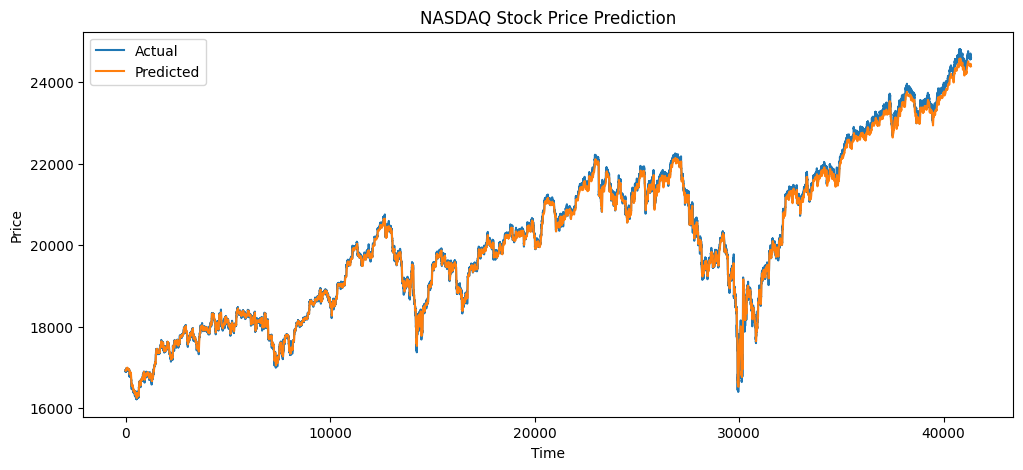

In [17]:
plt.figure(figsize=(12, 5))
plt.plot(actual_prices, label="Actual")
plt.plot(predicted_prices, label="Predicted")
plt.title("NASDAQ Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()